<a href="https://colab.research.google.com/github/douglasbaquiao/materials-solar-ml/blob/main/notebooks/v2_eda_campos_expandidos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Materials Informatics — EDA v2
## Perovskitas Duplas Halogenadas × Kesteritas para Aplicações Fotovoltaicas

**Versão:** 2.2 — validação metodológica completa, regime de cálculo e flag de análise

**Histórico de versões:**
- v2.0 — campos expandidos, integração com `extraction.py`, estrutura de pastas
- v2.1 — classificação por grupo espacial (`estrutura_esperada`)
- v2.2 — regime de cálculo via API (`regime_calc`), validação de referências, flag `usar_em_analise`

**Antes de executar:** configurar `MP_API_KEY` no painel Secrets do Colab (🔑) ou em `.env` local.

## 1. Configuração do Ambiente

In [10]:
import subprocess, sys, os

subprocess.run([
    sys.executable, "-m", "pip", "install",
    "mp-api", "pymatgen", "python-dotenv", "networkx==2.8.8", "-q"
])

try:
    from google.colab import userdata
    EM_COLAB = True
except ImportError:
    EM_COLAB = False

print(f"Ambiente: {'Google Colab' if EM_COLAB else 'Local (Jupyter / VS Code)'}")

Ambiente: Google Colab


### 1.1 Chave de API

- **Colab:** painel *Secrets* (🔑) → entrada `MP_API_KEY`
- **Local:** arquivo `.env` na raiz do projeto (nunca versionado)

In [11]:
if EM_COLAB:
    os.environ["MP_API_KEY"] = userdata.get("MP_API_KEY")
    print("Chave carregada via Colab Secrets.")
else:
    print("Chave será lida do .env ou da variável MP_API_KEY.")

Chave carregada via Colab Secrets.


## 2. Estrutura de Pastas do Repositório

```
materials-solar-ml/
├── src/extraction.py
├── notebooks/v2_eda_campos_expandidos.ipynb
├── data/processed/    ← CSVs gerados aqui
└── figures/           ← PNGs gerados aqui
```

In [12]:
REPO_URL  = "https://github.com/douglasbaquiao/materials-solar-ml.git"
REPO_NAME = "materials-solar-ml"

if EM_COLAB:
    repo_path = f"/content/{REPO_NAME}"
    if not os.path.exists(repo_path):
        subprocess.run(["git", "clone", REPO_URL, repo_path])
        print(f"Repositório clonado em {repo_path}")
    else:
        subprocess.run(["git", "-C", repo_path, "pull"])
        print(f"Repositório atualizado: {repo_path}")
    os.chdir(repo_path)

RAIZ = os.getcwd()
print(f"Raiz: {RAIZ}")

PASTA_PROCESSED = os.path.join(RAIZ, "data", "processed")
PASTA_FIGURES   = os.path.join(RAIZ, "figures")

for pasta in [os.path.join(RAIZ,"data","raw"), PASTA_PROCESSED, PASTA_FIGURES]:
    os.makedirs(pasta, exist_ok=True)
print("Pastas verificadas.")

Repositório atualizado: /content/materials-solar-ml
Raiz: /content/materials-solar-ml
Pastas verificadas.


## 3. Imports

In [13]:
import warnings, re
from collections import Counter, defaultdict
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.insert(0, os.path.join(RAIZ, "src"))

from extraction import (
    conectar_api, extrair_familia, adicionar_features,
    pipeline_completo, exportar, carregar,
    PV_GAP_MIN, PV_GAP_MAX, IBSC_GAP_MAX, HULL_THRESH, FAMILIAS,
    PV_GAP_MIN_AMP, PV_GAP_MAX_AMP,
    IBSC_GAP_MIN_AMP, IBSC_GAP_MAX_AMP,
)

plt.rcParams.update({
    "figure.dpi": 130,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})

FAMILIAS_PLOT = {
    "perovskita": {"label": "Perovskitas Duplas", "cor": "#E07B54"},
    "kesterita":  {"label": "Kesteritas",         "cor": "#4A90D9"},
}

# Cores para categorias estruturais — usadas em múltiplas figuras
ORDEM_CATS = ["perovskita dupla", "kesterita", "relacionada", "outra"]
CORES_CATS = {
    "perovskita dupla": "#E07B54",
    "kesterita":        "#4A90D9",
    "relacionada":      "#8B6CAD",
    "outra":            "#AAAAAA",
}

print("Imports concluídos.")
print(f"Janela PV:   {PV_GAP_MIN}–{PV_GAP_MAX} eV")
print(f"Janela IBSC: {PV_GAP_MAX}–{IBSC_GAP_MAX} eV")
print(f"Hull thresh: {HULL_THRESH} eV/átomo")

Imports concluídos.
Janela PV:   1.0–1.8 eV
Janela IBSC: 1.8–2.6 eV
Hull thresh: 0.05 eV/átomo


## 4. Extração de Dados

**Primeira execução:** descomentar `pipeline_completo()`.  
**Execuções seguintes:** manter apenas os `carregar()` — evita re-extrair da API.

In [14]:
# ── OPÇÃO A: primeira execução ────────────────────────────────────────────────
#dados = pipeline_completo(exportar_=True, verbose=True)
#df_p  = dados["perovskita"]
#df_k  = dados["kesterita"]

# ── OPÇÃO B: execuções seguintes ──────────────────────────────────────────────
df_p = carregar("perovskita", pasta=PASTA_PROCESSED)
df_k = carregar("kesterita",  pasta=PASTA_PROCESSED)

# ── Verificar se colunas ampliadas existem; se não, reaplicar features ────────
COLUNAS_NECESSARIAS = [
    "is_pv_candidate_amp", "is_ibsc_candidate_amp",
    "estrutura_esperada", "regime_calc", "usar_em_analise",
]

for chave, df in [("perovskita", df_p), ("kesterita", df_k)]:
    ausentes = [c for c in COLUNAS_NECESSARIAS if c not in df.columns]
    if ausentes:
        print(f"⚠ {chave}: colunas ausentes {ausentes} — reaplicando adicionar_features()")
        # Reaplicar apenas as features que vêm do extraction.py
        # (estrutura_esperada e regime_calc precisam ser recriadas separadamente)
        df = adicionar_features(df)
        if chave == "perovskita":
            df_p = df
        else:
            df_k = df

print(f"Perovskitas Duplas: {len(df_p):>5} materiais, {len(df_p.columns)} colunas")
print(f"Kesteritas:         {len(df_k):>5} materiais, {len(df_k.columns)} colunas")

# Confirmar presença das colunas críticas
for col in COLUNAS_NECESSARIAS:
    em_p = col in df_p.columns
    em_k = col in df_k.columns
    status = "✓" if em_p and em_k else "⚠"
    print(f"  {status} {col:<30} perovskita: {em_p}  kesterita: {em_k}")

  Carregado: /content/materials-solar-ml/data/processed/perovskita.csv  (6033 linhas, 53 colunas)
  Carregado: /content/materials-solar-ml/data/processed/kesterita.csv  (4367 linhas, 53 colunas)
Perovskitas Duplas:  6033 materiais, 53 colunas
Kesteritas:          4367 materiais, 53 colunas
  ✓ is_pv_candidate_amp            perovskita: True  kesterita: True
  ✓ is_ibsc_candidate_amp          perovskita: True  kesterita: True
  ✓ estrutura_esperada             perovskita: True  kesterita: True
  ✓ regime_calc                    perovskita: True  kesterita: True
  ✓ usar_em_analise                perovskita: True  kesterita: True


## 4.1 Validação de Sanidade do Dataset

Verificações automáticas executadas a cada sessão para garantir integridade
dos dados antes de qualquer análise.

In [15]:
def validar_dataframe(df, nome):
    erros = []

    # Ranges físicos plausíveis
    if (df["band_gap"] < 0).any():
        erros.append(f"band_gap negativo: {(df['band_gap']<0).sum()} casos")
    if (df["density"] <= 0).any():
        erros.append(f"density <= 0: {(df['density']<=0).sum()} casos")
    if (df["energy_above_hull"] < 0).any():
        erros.append(f"energy_above_hull negativo: {(df['energy_above_hull']<0).sum()} casos")

    # Consistência interna
    metal_pv = df[df["is_metal"] & df["is_pv_candidate"]]
    if len(metal_pv) > 0:
        erros.append(f"metais marcados como candidatos PV: {len(metal_pv)}")

    inconsistentes = df[df["is_stable"] & (df["energy_above_hull"] > 0.001)]
    if len(inconsistentes) > 0:
        erros.append(f"is_stable=True com hull>0: {len(inconsistentes)}")

    # NaN em colunas críticas
    for col in ["material_id", "formula", "band_gap", "is_metal",
                "energy_above_hull", "formation_energy_per_atom"]:
        n_nan = df[col].isna().sum()
        if n_nan > 0:
            erros.append(f"NaN em {col}: {n_nan}")

    # Duplicatas
    n_dup = df.duplicated(subset="material_id").sum()
    if n_dup > 0:
        erros.append(f"material_ids duplicados: {n_dup}")

    print(f"── Validação: {nome} ──")
    if erros:
        for e in erros:
            print(f"  ⚠ {e}")
    else:
        print("  ✓ Sem inconsistências detectadas")

validar_dataframe(df_p, "Perovskitas Duplas")
validar_dataframe(df_k, "Kesteritas")

── Validação: Perovskitas Duplas ──
  ✓ Sem inconsistências detectadas
── Validação: Kesteritas ──
  ✓ Sem inconsistências detectadas


## 4.2 Regime de Cálculo DFT via API

O Materials Project usa diferentes funcionais dependendo da composição:
- **GGA puro** — materiais sem metais de transição com elétrons d localizados
- **GGA+U** — materiais com Mn, Fe, Co, Cr, V, Ni, W, Mo em haletos/calcogenetos
- **HSE06** — cálculos híbridos para subconjunto (mais preciso, custo alto)
- **r2SCAN** — metaGGA mais recente (termodinâmica por padrão no MP desde 2023)

**Impacto:** gaps GGA e GGA+U **não são diretamente comparáveis** em escala absoluta.
Análises quantitativas (ML) devem ser estratificadas por regime.

**Estratégia de identificação:** `summary → task_ids → tasks → run_type` da tarefa Static.

In [16]:
def buscar_task_ids(df, mpr, verbose=True):
    # Busca task_ids se não estiverem no DataFrame (ex: primeira extração)
    if "task_ids" in df.columns and df["task_ids"].notna().any():
        if verbose:
            print("  task_ids já presentes no DataFrame.")
        return df

    if verbose:
        print(f"  Buscando task_ids para {len(df)} materiais...")

    docs = mpr.materials.summary.search(
        material_ids=df["material_id"].tolist(),
        fields=["material_id", "task_ids"]
    )
    mapa = {str(doc.material_id): [str(t) for t in doc.task_ids]
            for doc in docs if getattr(doc, "task_ids", None)}
    df["task_ids"] = df["material_id"].map(mapa)
    return df


def buscar_regime_por_task_ids(df, mpr, verbose=True):
    # Passo 1: mapear material_id → lista de task_ids
    mid_to_tids = {}
    for _, row in df.iterrows():
        tids = row.get("task_ids", None)
        if tids is None or (isinstance(tids, float)):
            continue
        if isinstance(tids, str):
            tids = re.findall("mp-[0-9]+", tids)
        else:
            tids = [str(t) for t in tids]
        mid_to_tids[row["material_id"]] = tids

    todos_task_ids = list({tid for tids in mid_to_tids.values() for tid in tids})

    if verbose:
        print(f"  Materiais com task_ids: {len(mid_to_tids)}")
        print(f"  Total task_ids únicos a consultar: {len(todos_task_ids)}")

    # Passo 2: buscar run_type e task_type em lote
    LOTE = 500
    tid_to_info = {}

    for i in range(0, len(todos_task_ids), LOTE):
        lote = todos_task_ids[i:i+LOTE]
        try:
            docs = mpr.materials.tasks.search(
                task_ids=lote,
                fields=["task_id", "run_type", "task_type"]
            )
            for doc in docs:
                tid_to_info[str(doc.task_id)] = {
                    "run_type":  str(getattr(doc, "run_type",  "")),
                    "task_type": str(getattr(doc, "task_type", "")),
                }
        except Exception as e:
            if verbose:
                print(f"  ⚠ Erro no lote {i//LOTE + 1}: {e}")

    if verbose:
        print(f"  task_ids com run_type obtido: {len(tid_to_info)}")

    # Passo 3: para cada material, pegar run_type da primeira tarefa Static encontrada
    def extrair_regime(material_id):
        tids = mid_to_tids.get(material_id, [])
        for tid in tids:
            info = tid_to_info.get(tid, {})
            if "Static" in info.get("task_type", "") and info.get("run_type", ""):
                return info["run_type"]
        return "desconhecido"

    df["regime_calc"] = df["material_id"].apply(extrair_regime)
    return df


# ── Executar (pode levar alguns minutos para datasets grandes) ────────────────
# Na primeira execução com regime_calc ausente, rodar:
mpr = conectar_api()
df_p = buscar_task_ids(df_p, mpr)
df_k = buscar_task_ids(df_k, mpr)
df_p = buscar_regime_por_task_ids(df_p, mpr, verbose=True)
df_k = buscar_regime_por_task_ids(df_k, mpr, verbose=True)
exportar(df_p, "perovskita", pasta=PASTA_PROCESSED)
exportar(df_k, "kesterita",  pasta=PASTA_PROCESSED)

# ── Verificar se regime_calc já está disponível (carregado do CSV) ────────────
for chave, df in [("Perovskitas Duplas", df_p), ("Kesteritas", df_k)]:
    if "regime_calc" not in df.columns:
        print(f"⚠ {chave}: regime_calc ausente — executar bloco acima")
    else:
        print(f"\n── {chave} (n={len(df)}) ──")
        ct = df["regime_calc"].value_counts()
        for regime, n in ct.items():
            pct = 100 * n / len(df)
            print(f"  {regime:<25} {n:>5}  ({pct:.1f}%)")

  task_ids já presentes no DataFrame.
  task_ids já presentes no DataFrame.
  Materiais com task_ids: 6033
  Total task_ids únicos a consultar: 40003


Retrieving CoreTaskDoc documents:   0%|          | 0/500 [00:00<?, ?it/s]

Retrieving CoreTaskDoc documents:   0%|          | 0/500 [00:00<?, ?it/s]

Retrieving CoreTaskDoc documents:   0%|          | 0/500 [00:00<?, ?it/s]

Retrieving CoreTaskDoc documents:   0%|          | 0/500 [00:00<?, ?it/s]

...

Retrieving CoreTaskDoc documents:   0%|          | 0/500 [00:00<?, ?it/s]

Retrieving CoreTaskDoc documents:   0%|          | 0/500 [00:00<?, ?it/s]

Retrieving CoreTaskDoc documents:   0%|          | 0/500 [00:00<?, ?it/s]

Retrieving CoreTaskDoc documents:   0%|          | 0/459 [00:00<?, ?it/s]

  task_ids com run_type obtido: 26943
  Exportado: /content/materials-solar-ml/data/processed/perovskita.csv  (6033 linhas, 53 colunas)
  Exportado: /content/materials-solar-ml/data/processed/kesterita.csv  (4367 linhas, 53 colunas)

── Perovskitas Duplas (n=6033) ──
  GGA                        3540  (58.7%)
  GGA+U                      2076  (34.4%)
  desconhecido                377  (6.2%)
  HSE06                        37  (0.6%)
  r2SCAN                        3  (0.0%)

── Kesteritas (n=4367) ──
  GGA                        3811  (87.3%)
  GGA+U                       352  (8.1%)
  desconhecido                177  (4.1%)
  HSE06                        24  (0.5%)
  r2SCAN                        3  (0.1%)


## 4.3 Validação de Materiais de Referência

Verificação spot-check contra materiais com propriedades conhecidas.
Os valores esperados são calibrados para o **nível de teoria DFT usado** (não experimental),
com notas sobre a discrepância esperada.

**Resultado da validação manual (conferência no site do Materials Project):**
- 6 materiais aleatórios (3 por família) confirmados com gap, sistema cristalino
  e energy above hull consistentes com os dados extraídos.
- Cs₂AgBiBr₆: gap indireto 1.35 eV, Fm-3m, NM — todos os campos corretos.

In [17]:
# Valores esperados calibrados para DFT — não para experimental
# Fonte: verificação manual no Materials Project (março 2026)
REFERENCIAS = {
    "mp-1078250": ("band_gap", 1.35, 0.15,
                   "Cs2AgBiBr6 — GGA NSCF. Gap indireto, Fm-3m, NM. "
                   "Experimental ~2.2 eV (subestimação PBE ~38%)"),
    "mp-1079541": ("band_gap", 0.09, 0.05,
                   "Cu2ZnSnS4 CZTS — GGA Struct. Opt. spacegroup=82 (kesterita ordenada). "
                   "Gap GGA ~0.09 eV; HSE06 ~1.18 eV; experimental ~1.5 eV"),
    "mp-1294897": ("band_gap", 1.69, 0.15,
                   "KMnIO6 — GGA+U Static. Gap 1.69 eV, FM, C2 (monoclínico). "
                   "Estrutura 'outra' — fora das famílias pretendidas. "
                   "Exemplo de falso positivo do filtro composicional"),
}

df_todos = pd.concat([df_p, df_k], ignore_index=True)

print("── Verificação de materiais de referência ──")
for mp_id, (prop, valor_esp, tol, descricao) in REFERENCIAS.items():
    row = df_todos[df_todos["material_id"] == mp_id]
    if len(row) == 0:
        print(f"\n  ? {mp_id}: não encontrado — verificar filtros de extração")
        continue
    r       = row.iloc[0]
    valor   = r[prop]
    regime  = r.get("regime_calc", "N/A") if "regime_calc" in r.index else "N/A"
    estrut  = r.get("estrutura_esperada", "N/A") if "estrutura_esperada" in r.index else "N/A"
    ok      = abs(valor - valor_esp) <= tol
    status  = "✓" if ok else "⚠"
    print(f"\n  {status} {mp_id}")
    print(f"     {descricao}")
    print(f"     {prop}: {valor:.3f} eV  |  regime: {regime}  |  estrutura: {estrut}")

── Verificação de materiais de referência ──

  ✓ mp-1078250
     Cs2AgBiBr6 — GGA NSCF. Gap indireto, Fm-3m, NM. Experimental ~2.2 eV (subestimação PBE ~38%)
     band_gap: 1.355 eV  |  regime: GGA  |  estrutura: perovskita dupla

  ✓ mp-1079541
     Cu2ZnSnS4 CZTS — GGA Struct. Opt. spacegroup=82 (kesterita ordenada). Gap GGA ~0.09 eV; HSE06 ~1.18 eV; experimental ~1.5 eV
     band_gap: 0.094 eV  |  regime: GGA  |  estrutura: kesterita

  ✓ mp-1294897
     KMnIO6 — GGA+U Static. Gap 1.69 eV, FM, C2 (monoclínico). Estrutura 'outra' — fora das famílias pretendidas. Exemplo de falso positivo do filtro composicional
     band_gap: 1.686 eV  |  regime: GGA+U  |  estrutura: outra


## 5. Classificação por Grupo Espacial

A extração composicional captura compostos fora das famílias pretendidas.
A coluna `estrutura_esperada` classifica cada material com base no grupo espacial.

**Perovskitas Duplas A₂B'B''X₆ — grupos canônicos:**

| Nº | Símbolo | Sistema | Tipo |
|---|---|---|---|
| 225 | Fm-3m | Cúbico | Protótipo ideal (Cs₂AgBiBr₆) |
| 139 | I4/mmm | Tetragonal | Distorção tetragonal comum |
| 123 | P4/mmm | Tetragonal | Distorção leve |
| 62 | Pnma | Ortorrômbico | Distorção Glazer a⁻b⁺a⁻ |
| 74 | Imma | Ortorrômbico | Distorção intermediária |
| 12, 2 | C2/m, P-1 | Mono/Tri | Alta distorção — *relacionada* |

**Kesteritas A₂BCX₄ — grupos canônicos:**

| Nº | Símbolo | Sistema | Tipo |
|---|---|---|---|
| 82 | I-4 | Tetragonal | Kesterita ordenada (CZTS) |
| 121 | I-42m | Tetragonal | Estannita |
| 119 | I-4m2 | Tetragonal | Kesterita primitiva |
| 122, 160 | I-42d, R3m | Tet./Trig. | Calcopirita/desordenada — *relacionada* |

In [18]:
GS_PEROVSKITA_DUPLA = {225, 139, 123, 62, 74}
GS_PEROVSKITA_REL   = {12, 2}
GS_KESTERITA        = {82, 121, 119}
GS_KESTERITA_REL    = {122, 160}

def classificar_estrutura(sg_number, gs_confirmados, gs_relacionados, nome_familia):
    if pd.isna(sg_number):
        return "outra"
    sg = int(sg_number)
    if sg in gs_confirmados:
        return nome_familia
    if sg in gs_relacionados:
        return "relacionada"
    return "outra"

# Aplicar apenas se coluna ausente (preserva versão já calculada no CSV)
if "estrutura_esperada" not in df_p.columns:
    df_p["estrutura_esperada"] = df_p["spacegroup_number"].apply(
        lambda sg: classificar_estrutura(sg, GS_PEROVSKITA_DUPLA, GS_PEROVSKITA_REL, "perovskita dupla"))

if "estrutura_esperada" not in df_k.columns:
    df_k["estrutura_esperada"] = df_k["spacegroup_number"].apply(
        lambda sg: classificar_estrutura(sg, GS_KESTERITA, GS_KESTERITA_REL, "kesterita"))

print("Distribuição de estrutura_esperada:")
for chave, df in [("Perovskitas Duplas", df_p), ("Kesteritas", df_k)]:
    print(f"\n── {chave} ──")
    ct = df["estrutura_esperada"].value_counts()
    for cat, n in ct.items():
        print(f"  {cat:<20} {n:>5}  ({100*n/len(df):.1f}%)")

Distribuição de estrutura_esperada:

── Perovskitas Duplas ──
  outra                 3293  (54.6%)
  perovskita dupla      2105  (34.9%)
  relacionada            635  (10.5%)

── Kesteritas ──
  outra                 4126  (94.5%)
  kesterita              148  (3.4%)
  relacionada             93  (2.1%)


## 6. Flag de Qualidade — `usar_em_analise`

Combina as duas dimensões de qualidade construídas nas seções anteriores
num único critério booleano para uso nas visualizações e modelos.

**Critérios de exclusão:**
- `regime_calc == "desconhecido"` — sem tarefa Static encontrada na API
  (maioria com apenas 1 task_id = só otimização de estrutura, sem cálculo eletrônico dedicado)
- `estrutura_esperada == "outra"` — grupo espacial incompatível com a família pretendida

**Materiais excluídos permanecem no DataFrame** — são filtrados explicitamente
nas análises, não apagados, garantindo rastreabilidade.

In [19]:
# Aplicar apenas se coluna ausente
if "usar_em_analise" not in df_p.columns:
    df_p["usar_em_analise"] = (
        (df_p["regime_calc"] != "desconhecido") &
        (df_p["estrutura_esperada"] != "outra")
    )

if "usar_em_analise" not in df_k.columns:
    df_k["usar_em_analise"] = (
        (df_k["regime_calc"] != "desconhecido") &
        (df_k["estrutura_esperada"] != "outra")
    )

print("── Resumo do flag usar_em_analise ──")
for chave, df in [("Perovskitas Duplas", df_p), ("Kesteritas", df_k)]:
    n_total   = len(df)
    n_usar    = df["usar_em_analise"].sum()
    n_excluir = n_total - n_usar
    print(f"\n{chave} (total={n_total}):")
    print(f"  Para análise:  {n_usar:>5}  ({100*n_usar/n_total:.1f}%)")
    print(f"  Excluídos:     {n_excluir:>5}  ({100*n_excluir/n_total:.1f}%)")

    # Detalhamento dos excluídos
    excl = df[~df["usar_em_analise"]]
    print(f"  Motivo de exclusão:")
    n_desc  = (excl["regime_calc"] == "desconhecido").sum()
    n_outra = (excl["estrutura_esperada"] == "outra").sum()
    n_ambos = ((excl["regime_calc"] == "desconhecido") &
               (excl["estrutura_esperada"] == "outra")).sum()
    print(f"    regime desconhecido: {n_desc}")
    print(f"    estrutura outra:     {n_outra}")
    print(f"    ambos:               {n_ambos}")

# Persistir com todas as colunas novas
exportar(df_p, "perovskita", pasta=PASTA_PROCESSED)
exportar(df_k, "kesterita",  pasta=PASTA_PROCESSED)
print("\nCSVs atualizados: estrutura_esperada, regime_calc, usar_em_analise")

── Resumo do flag usar_em_analise ──

Perovskitas Duplas (total=6033):
  Para análise:   2719  (45.1%)
  Excluídos:      3314  (54.9%)
  Motivo de exclusão:
    regime desconhecido: 377
    estrutura outra:     3293
    ambos:               356

Kesteritas (total=4367):
  Para análise:    234  (5.4%)
  Excluídos:      4133  (94.6%)
  Motivo de exclusão:
    regime desconhecido: 177
    estrutura outra:     4126
    ambos:               170
  Exportado: /content/materials-solar-ml/data/processed/perovskita.csv  (6033 linhas, 53 colunas)
  Exportado: /content/materials-solar-ml/data/processed/kesterita.csv  (4367 linhas, 53 colunas)

CSVs atualizados: estrutura_esperada, regime_calc, usar_em_analise


## 7. Cobertura dos Campos v2

Campos com cobertura abaixo de ~20% são mantidos no dataset mas reservados
para análise individual dos candidatos finais (Fase 4), onde o subconjunto
pequeno permite buscar dados adicionais por material.

In [20]:
def cobertura_campos(df, nome):
    campos = [
        "efermi", "e_electronic", "e_ionic", "e_total", "n_refractive",
        "weighted_work_function", "weighted_surface_energy",
        "bulk_modulus_vrh", "shear_modulus_vrh",
        "has_dielectric_data", "has_elastic_data", "has_experimental_ref",
    ]
    print(f"\n── {nome} (n={len(df)}) ──")
    for campo in campos:
        if campo not in df.columns:
            continue
        n = df[campo].sum() if df[campo].dtype == bool else df[campo].notna().sum()
        pct   = 100 * n / len(df)
        barra = "█" * int(pct / 5) + "░" * (20 - int(pct / 5))
        print(f"  {campo:<35} {barra}  {n:>5}/{len(df)} ({pct:5.1f}%)")

cobertura_campos(df_p, "Perovskitas Duplas")
cobertura_campos(df_k, "Kesteritas")


── Perovskitas Duplas (n=6033) ──
  efermi                              ████████████████████   6033/6033 (100.0%)
  e_electronic                        ░░░░░░░░░░░░░░░░░░░░    280/6033 (  4.6%)
  e_ionic                             ░░░░░░░░░░░░░░░░░░░░    280/6033 (  4.6%)
  e_total                             ░░░░░░░░░░░░░░░░░░░░    280/6033 (  4.6%)
  n_refractive                        ░░░░░░░░░░░░░░░░░░░░    280/6033 (  4.6%)
  weighted_work_function              ░░░░░░░░░░░░░░░░░░░░      0/6033 (  0.0%)
  weighted_surface_energy             ░░░░░░░░░░░░░░░░░░░░      0/6033 (  0.0%)
  bulk_modulus_vrh                    ░░░░░░░░░░░░░░░░░░░░      0/6033 (  0.0%)
  shear_modulus_vrh                   ░░░░░░░░░░░░░░░░░░░░      0/6033 (  0.0%)
  has_dielectric_data                 ░░░░░░░░░░░░░░░░░░░░    280/6033 (  4.6%)
  has_elastic_data                    ░░░░░░░░░░░░░░░░░░░░      0/6033 (  0.0%)
  has_experimental_ref                █████░░░░░░░░░░░░░░░   1688/6033 ( 28.0%)

── K

## 8. Análise Estatística

Estatísticas sobre o **subconjunto de análise** (`usar_em_analise == True`),
estratificadas por regime de cálculo onde relevante.

In [21]:
METRICAS_CORE = [
    "band_gap", "formation_energy_per_atom", "energy_above_hull",
    "density", "nsites", "volume", "site_density", "efermi",
]

for chave, df in [("perovskita", df_p), ("kesterita", df_k)]:
    nome = FAMILIAS_PLOT[chave]["label"]
    sub  = df[df["usar_em_analise"]]
    cols = [m for m in METRICAS_CORE if m in sub.columns]
    print(f"\n{'='*68}")
    print(f"{nome.upper()} — subconjunto de análise (n={len(sub)})")
    print(sub[cols].describe().round(3).to_string())

# ── Comparação de gap médio por regime ───────────────────────────────────────
print(f"\n{'='*68}")
print("BAND GAP MÉDIO POR REGIME DE CÁLCULO (não-metais, usar_em_analise=True)")
for chave, df in [("perovskita", df_p), ("kesterita", df_k)]:
    nome = FAMILIAS_PLOT[chave]["label"]
    sub  = df[df["usar_em_analise"] & ~df["is_metal"]]
    print(f"\n── {nome} ──")
    resumo = (
        sub.groupby("regime_calc")["band_gap"]
        .agg(["mean","median","std","count"])
        .round(3)
    )
    print(resumo.to_string())

# ── Sumário de candidatos ─────────────────────────────────────────────────────
print(f"\n{'='*68}")
print("CANDIDATOS (subconjunto de análise)")
linhas = [
    ("PV restrito (1.0–1.8 eV)",      "is_pv_candidate"),
    ("PV ampliado (0.7–2.0 eV)",       "is_pv_candidate_amp"),
    ("IBSC restrito (1.8–2.6 eV)",     "is_ibsc_candidate"),
    ("IBSC ampliado (1.4–3.2 eV)",     "is_ibsc_candidate_amp"),
    ("Estáveis (hull=0)",   "is_stable"),
    ("Quasi (<50 meV)",     "near_hull"),
    ("Com ref. experimental","has_experimental_ref"),
]
for descricao, col in linhas:
    print(f"\n  {descricao}")
    for chave, df in [("perovskita", df_p), ("kesterita", df_k)]:
        nome = FAMILIAS_PLOT[chave]["label"]
        sub  = df[df["usar_em_analise"]]
        if col not in sub.columns:
            continue
        n   = sub[col].sum()
        pct = 100 * n / len(sub)
        print(f"    {nome:22s}: {n:>4}/{len(sub):<5} ({pct:5.1f}%)")


PEROVSKITAS DUPLAS — subconjunto de análise (n=2719)
       band_gap  formation_energy_per_atom  energy_above_hull   density    nsites    volume  site_density    efermi
count  2719.000                   2719.000           2719.000  2719.000  2719.000  2719.000      2719.000  2719.000
mean      1.257                     -1.859              0.167     3.948    14.495   344.068         0.047     0.961
std       1.250                      0.857              0.402     1.142     8.125   204.816         0.021     1.605
min       0.000                     -3.972              0.000     0.455     4.000    38.955         0.007    -5.808
25%       0.000                     -2.484              0.010     3.200    10.000   200.512         0.030    -0.075
50%       0.969                     -1.935              0.065     3.812    10.000   302.159         0.043     0.794
75%       2.286                     -1.367              0.141     4.493    17.000   412.844         0.060     1.917
max       3.999   

## 9. Análise por Categoria Estrutural

Compara propriedades entre categorias de `estrutura_esperada`.
Informa a decisão sobre quais materiais usar nas análises seguintes.

In [22]:
def sumario_por_categoria(df, nome_familia):
    metricas = ["band_gap", "formation_energy_per_atom",
                "energy_above_hull", "density", "efermi"]
    print(f"\n{'='*68}")
    print(f"{nome_familia.upper()} — médias por categoria estrutural")
    cols = [m for m in metricas if m in df.columns]
    resumo = df.groupby("estrutura_esperada")[cols].agg(["mean","max", "min","median","count"]).round(3)
    print(resumo.to_string())
    print(f"\n── Candidatos PV por categoria ──")
    for cat in df["estrutura_esperada"].unique():
        sub  = df[df["estrutura_esperada"] == cat]
        n_pv = sub["is_pv_candidate"].sum()
        pct  = 100 * n_pv / len(sub) if len(sub) > 0 else 0
        print(f"  {cat:<20} PV: {n_pv:>4}/{len(sub):<5} ({pct:.1f}%)")

sumario_por_categoria(df_p, "Perovskitas Duplas")
sumario_por_categoria(df_k, "Kesteritas")


PEROVSKITAS DUPLAS — médias por categoria estrutural
                   band_gap                          formation_energy_per_atom                            energy_above_hull                          density                            efermi                            
                       mean    max  min median count                      mean    max    min median count              mean    max  min median count    mean    max    min median count   mean     max    min median count
estrutura_esperada                                                                                                                                                                                                        
outra                 1.105  3.998  0.0  0.877  3293                    -1.929  3.626 -4.066 -2.100  3293             0.227  5.813  0.0  0.107  3293   3.907  9.353  0.342  3.883  3293  1.288  12.402 -6.300  1.494  3293
perovskita dupla      1.243  3.999  0.0  0.911  2105                  

In [32]:
# Teste rápido das janelas ampliadas
for chave, df in [("Perovskitas Duplas", df_p), ("Kesteritas", df_k)]:
    sub = df[df["usar_em_analise"] & ~df["is_metal"]]
    n_pv_rest = sub["is_pv_candidate"].sum()
    n_pv_amp  = sub["is_pv_candidate_amp"].sum()
    n_ib_rest = sub["is_ibsc_candidate"].sum()
    n_ib_amp  = sub["is_ibsc_candidate_amp"].sum()
    print(f"\n{chave}:")
    print(f"  PV  restrito (1.0–1.8): {n_pv_rest:>5}  |  ampliado (0.7–2.0): {n_pv_amp:>5}  |  exclusivos ampliados: {n_pv_amp - n_pv_rest:>5}")
    print(f"  IBSC restrito (1.8–2.6): {n_ib_rest:>4}  |  ampliado (1.4–3.2): {n_ib_amp:>5}  |  exclusivos ampliados: {n_ib_amp - n_ib_rest:>5}")


Perovskitas Duplas:
  PV  restrito (1.0–1.8):   393  |  ampliado (0.7–2.0):   652  |  exclusivos ampliados:   259
  IBSC restrito (1.8–2.6):  430  |  ampliado (1.4–3.2):   897  |  exclusivos ampliados:   467

Kesteritas:
  PV  restrito (1.0–1.8):    18  |  ampliado (0.7–2.0):    37  |  exclusivos ampliados:    19
  IBSC restrito (1.8–2.6):   15  |  ampliado (1.4–3.2):    27  |  exclusivos ampliados:    12


Salvo: /content/materials-solar-ml/figures/figA_gap_por_estrutura.png


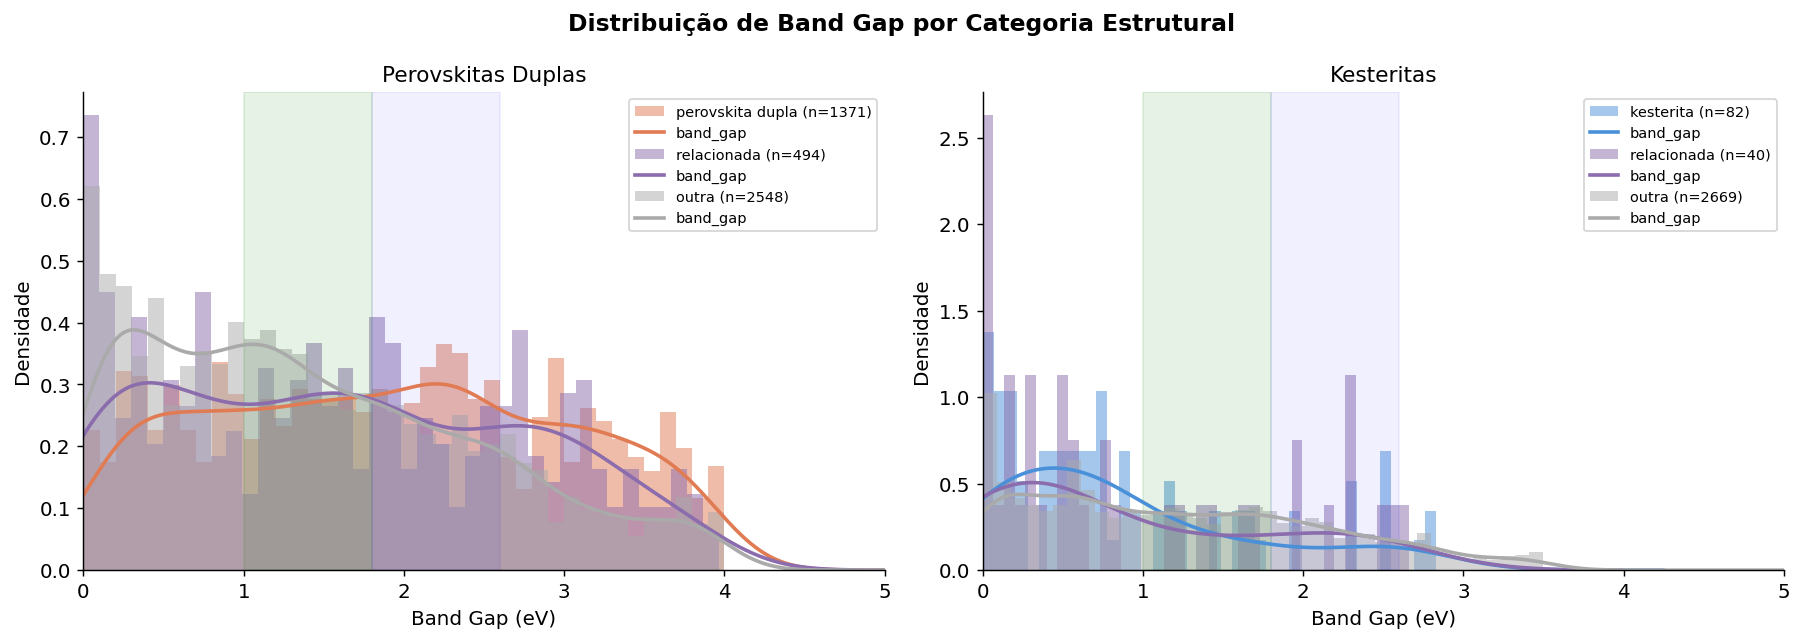

In [23]:
# ── Fig. A — Band gap por categoria estrutural ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Distribuição de Band Gap por Categoria Estrutural",
             fontsize=13, fontweight="bold")

for ax, (chave, df) in zip(axes, [("perovskita", df_p), ("kesterita", df_k)]):
    cfg = FAMILIAS_PLOT[chave]
    for cat in ORDEM_CATS:
        if cat not in df["estrutura_esperada"].unique():
            continue
        sub   = df[(df["estrutura_esperada"] == cat) & (~df["is_metal"])]
        dados = sub["band_gap"].dropna()
        if len(dados) < 5:
            continue
        cor = CORES_CATS.get(cat, "#999999")
        ax.hist(dados, bins=40, alpha=0.5, color=cor,
                density=True, label=f"{cat} (n={len(dados)})")
        if len(dados) > 20:
            dados.plot.kde(ax=ax, color=cor, linewidth=2)

    ax.axvspan(PV_GAP_MIN, PV_GAP_MAX,   alpha=0.10, color="green")
    ax.axvspan(PV_GAP_MAX, IBSC_GAP_MAX, alpha=0.06, color="blue")
    ax.set_xlabel("Band Gap (eV)", fontsize=11)
    ax.set_ylabel("Densidade", fontsize=11)
    ax.set_title(cfg["label"], fontsize=12)
    ax.legend(fontsize=8)
    ax.set_xlim(0, 5)

plt.tight_layout()
caminho = os.path.join(PASTA_FIGURES, "figA_gap_por_estrutura.png")
plt.savefig(caminho, dpi=150, bbox_inches="tight")
print(f"Salvo: {caminho}")
plt.show()

## 10. Visualizações

Todas as figuras usam o subconjunto `usar_em_analise == True`.
Estratificação por `regime_calc` incluída onde o impacto é relevante.

### Fig. 1 — Distribuição de Band Gap

Salvo: /content/materials-solar-ml/figures/fig1_distribuicao_gap.png


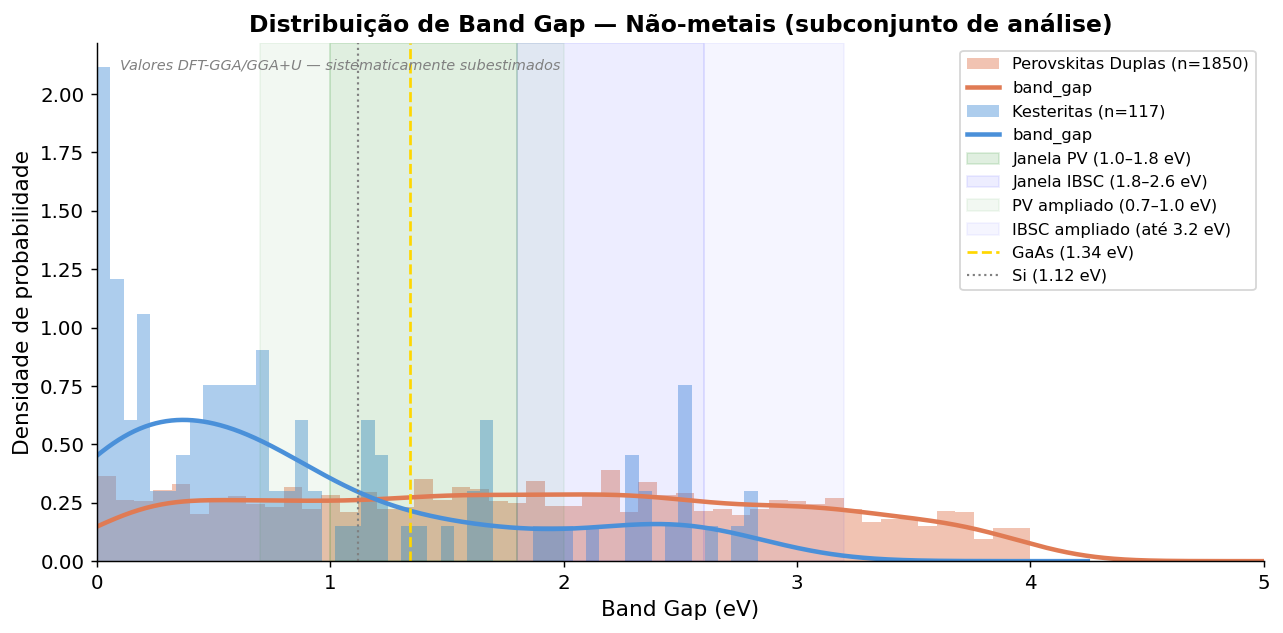

In [24]:
fig, ax = plt.subplots(figsize=(10, 5))

for chave, df in [("perovskita", df_p), ("kesterita", df_k)]:
    cfg   = FAMILIAS_PLOT[chave]
    sub   = df[df["usar_em_analise"] & ~df["is_metal"]]
    dados = sub["band_gap"].dropna()
    ax.hist(dados, bins=50, alpha=0.45, color=cfg["cor"],
            density=True, label=f"{cfg['label']} (n={len(dados)})")
    dados.plot.kde(ax=ax, color=cfg["cor"], linewidth=2.5)

ax.axvspan(PV_GAP_MIN,   PV_GAP_MAX,   alpha=0.12, color="green",
           label=f"Janela PV ({PV_GAP_MIN}–{PV_GAP_MAX} eV)")
ax.axvspan(PV_GAP_MAX,   IBSC_GAP_MAX, alpha=0.07, color="blue",
           label=f"Janela IBSC ({PV_GAP_MAX}–{IBSC_GAP_MAX} eV)")

# Janelas ampliadas
ax.axvspan(PV_GAP_MIN_AMP, PV_GAP_MIN,     alpha=0.05, color="green",
           label=f"PV ampliado ({PV_GAP_MIN_AMP}–{PV_GAP_MIN} eV)")
ax.axvspan(PV_GAP_MAX,     PV_GAP_MAX_AMP, alpha=0.05, color="green")
ax.axvspan(IBSC_GAP_MAX,   IBSC_GAP_MAX_AMP, alpha=0.04, color="blue",
           label=f"IBSC ampliado (até {IBSC_GAP_MAX_AMP} eV)")

ax.axvline(1.34, color="gold", linestyle="--", linewidth=1.5, label="GaAs (1.34 eV)")
ax.axvline(1.12, color="gray", linestyle=":",  linewidth=1.2, label="Si (1.12 eV)")
ax.text(0.02, 0.97, "Valores DFT-GGA/GGA+U — sistematicamente subestimados",
        transform=ax.transAxes, fontsize=8, color="gray",
        va="top", style="italic")

ax.set_xlabel("Band Gap (eV)", fontsize=12)
ax.set_ylabel("Densidade de probabilidade", fontsize=12)
ax.set_title("Distribuição de Band Gap — Não-metais (subconjunto de análise)",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=9)
ax.set_xlim(0, 5)

plt.tight_layout()
caminho = os.path.join(PASTA_FIGURES, "fig1_distribuicao_gap.png")
plt.savefig(caminho, dpi=150, bbox_inches="tight")
print(f"Salvo: {caminho}")
plt.show()

### Fig. 2 — Estabilidade Termodinâmica

Salvo: /content/materials-solar-ml/figures/fig2_estabilidade.png


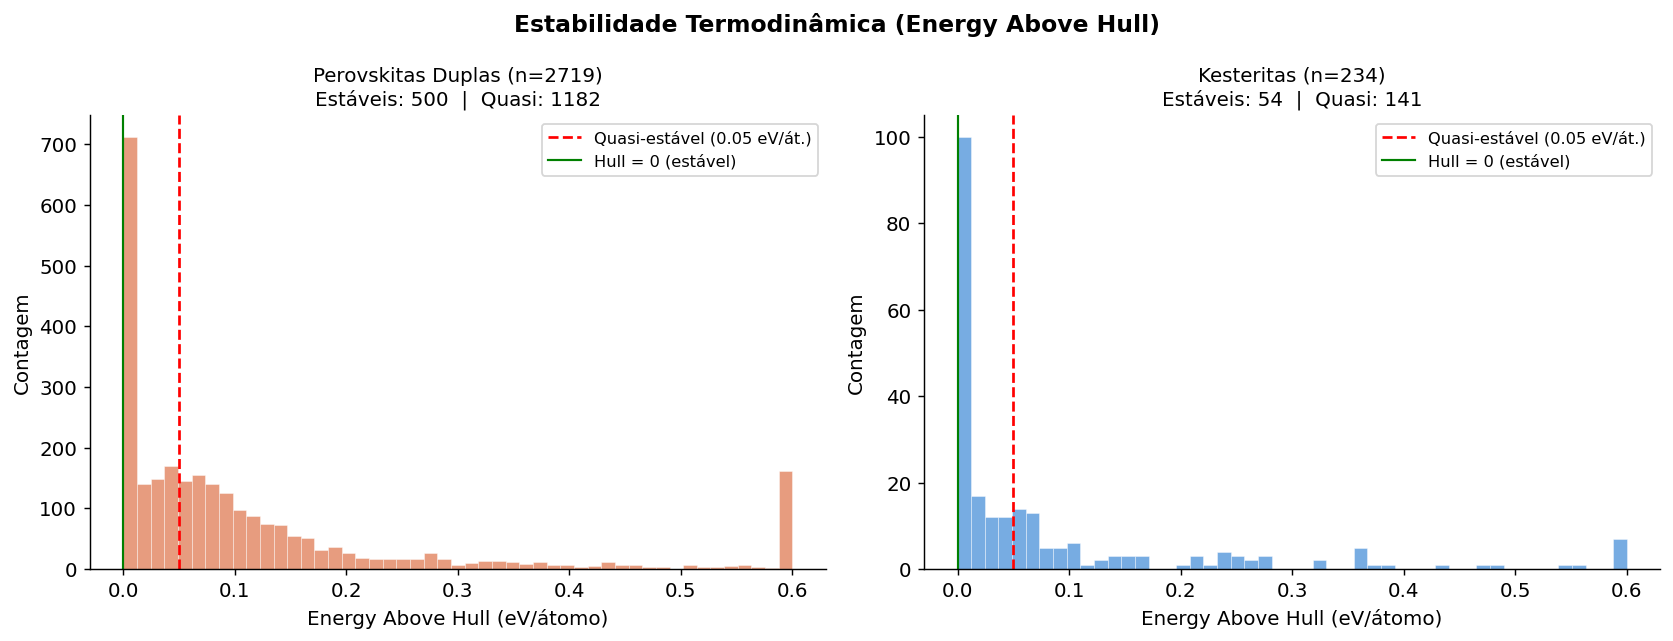

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Estabilidade Termodinâmica (Energy Above Hull)",
             fontsize=13, fontweight="bold")
bins = np.linspace(0, 0.6, 50)

for ax, (chave, df) in zip(axes, [("perovskita", df_p), ("kesterita", df_k)]):
    cfg = FAMILIAS_PLOT[chave]
    sub = df[df["usar_em_analise"]]
    ax.hist(sub["energy_above_hull"].clip(upper=0.6), bins=bins,
            color=cfg["cor"], alpha=0.75, edgecolor="white", linewidth=0.3)
    ax.axvline(HULL_THRESH, color="red",   linestyle="--", linewidth=1.5,
               label=f"Quasi-estável ({HULL_THRESH} eV/át.)")
    ax.axvline(0.0,         color="green", linestyle="-",  linewidth=1.2,
               label="Hull = 0 (estável)")
    n_est   = (sub["energy_above_hull"] == 0).sum()
    n_quasi = (sub["energy_above_hull"] < HULL_THRESH).sum()
    ax.set_title(f"{cfg['label']} (n={len(sub)})\nEstáveis: {n_est}  |  Quasi: {n_quasi}",
                 fontsize=11)
    ax.set_xlabel("Energy Above Hull (eV/átomo)", fontsize=11)
    ax.set_ylabel("Contagem", fontsize=11)
    ax.legend(fontsize=9)

plt.tight_layout()
caminho = os.path.join(PASTA_FIGURES, "fig2_estabilidade.png")
plt.savefig(caminho, dpi=150, bbox_inches="tight")
print(f"Salvo: {caminho}")
plt.show()

### Fig. 3 — Energia de Formação × Band Gap

Salvo: /content/materials-solar-ml/figures/fig3_formacao_vs_gap.png


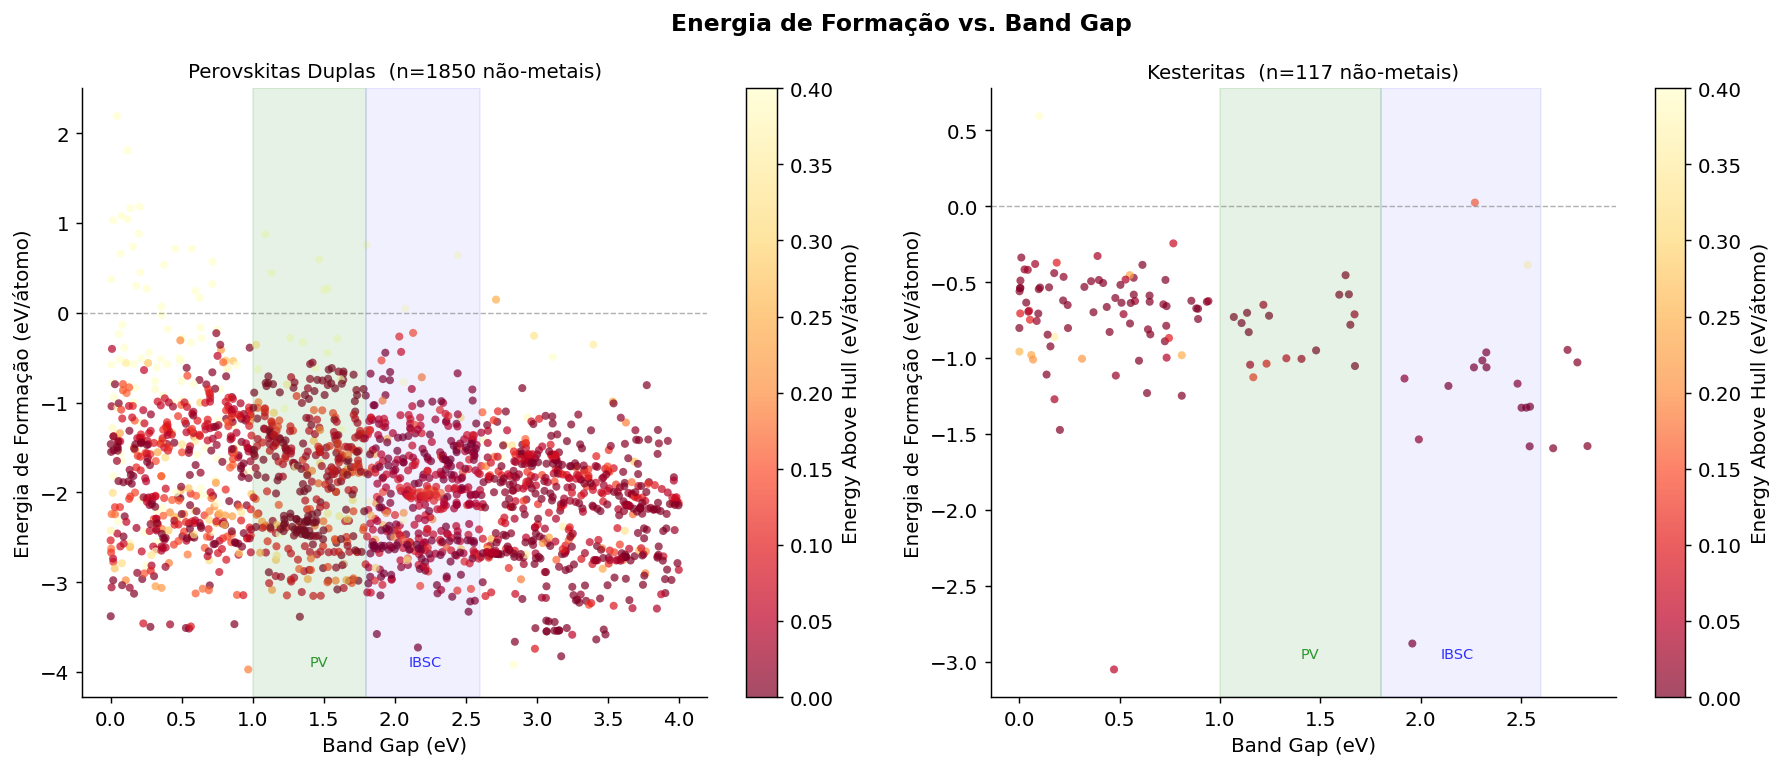

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Energia de Formação vs. Band Gap", fontsize=13, fontweight="bold")

for ax, (chave, df) in zip(axes, [("perovskita", df_p), ("kesterita", df_k)]):
    cfg = FAMILIAS_PLOT[chave]
    sub = df[df["usar_em_analise"] & ~df["is_metal"]].dropna(
        subset=["band_gap", "formation_energy_per_atom", "energy_above_hull"])
    sc = ax.scatter(sub["band_gap"], sub["formation_energy_per_atom"],
                    c=sub["energy_above_hull"].clip(upper=0.5),
                    cmap="YlOrRd_r", s=20, alpha=0.7,
                    vmin=0, vmax=0.4, edgecolors="none")
    plt.colorbar(sc, ax=ax, label="Energy Above Hull (eV/átomo)")
    ax.axvspan(PV_GAP_MIN, PV_GAP_MAX,   alpha=0.10, color="green")
    ax.axvspan(PV_GAP_MAX, IBSC_GAP_MAX, alpha=0.06, color="blue")
    ax.axhline(0, color="gray", linewidth=0.8, linestyle="--", alpha=0.6)
    ax.set_xlabel("Band Gap (eV)", fontsize=11)
    ax.set_ylabel("Energia de Formação (eV/átomo)", fontsize=11)
    ax.set_title(f"{cfg['label']}  (n={len(sub)} não-metais)", fontsize=11)
    ymin = ax.get_ylim()[0]
    ax.text(1.4, ymin * 0.92, "PV",   fontsize=8, color="green", alpha=0.8)
    ax.text(2.1, ymin * 0.92, "IBSC", fontsize=8, color="blue",  alpha=0.8)

plt.tight_layout()
caminho = os.path.join(PASTA_FIGURES, "fig3_formacao_vs_gap.png")
plt.savefig(caminho, dpi=150, bbox_inches="tight")
print(f"Salvo: {caminho}")
plt.show()

### Fig. 4 — Sistema Cristalino

Salvo: /content/materials-solar-ml/figures/fig4_sistemas_cristalinos.png


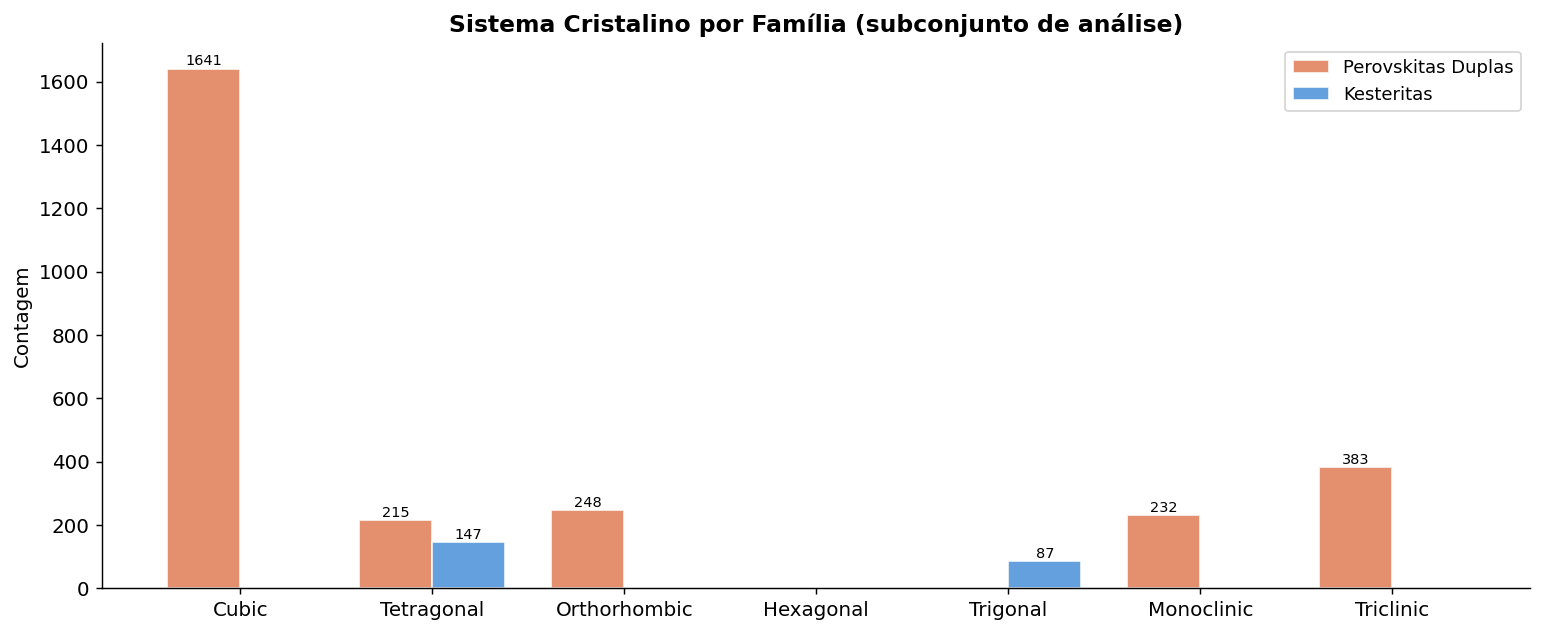

In [27]:
sistemas_ordem = ["cubic","tetragonal","orthorhombic",
                  "hexagonal","trigonal","monoclinic","triclinic"]

fig, ax = plt.subplots(figsize=(12, 5))
x, width = np.arange(len(sistemas_ordem)), 0.38

for offset, (chave, df) in zip([-width/2, width/2],
                                [("perovskita", df_p), ("kesterita", df_k)]):
    cfg  = FAMILIAS_PLOT[chave]
    sub  = df[df["usar_em_analise"]]
    ct   = sub["crystal_system"].str.lower().value_counts()
    vals = [ct.get(s, 0) for s in sistemas_ordem]
    bars = ax.bar(x + offset, vals, width, label=cfg["label"],
                  color=cfg["cor"], alpha=0.85, edgecolor="white")
    for bar, v in zip(bars, vals):
        if v > 0:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                    str(v), ha="center", va="bottom", fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels([s.capitalize() for s in sistemas_ordem], fontsize=11)
ax.set_ylabel("Contagem", fontsize=11)
ax.set_title("Sistema Cristalino por Família (subconjunto de análise)",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
plt.tight_layout()
caminho = os.path.join(PASTA_FIGURES, "fig4_sistemas_cristalinos.png")
plt.savefig(caminho, dpi=150, bbox_inches="tight")
print(f"Salvo: {caminho}")
plt.show()

### Fig. 5 — Nível de Fermi (efermi)

`efermi` é o campo v2 com maior cobertura. Plotado por regime de cálculo
para verificar se GGA e GGA+U produzem distribuições sistematicamente diferentes.

Salvo: /content/materials-solar-ml/figures/fig5_efermi_por_regime.png


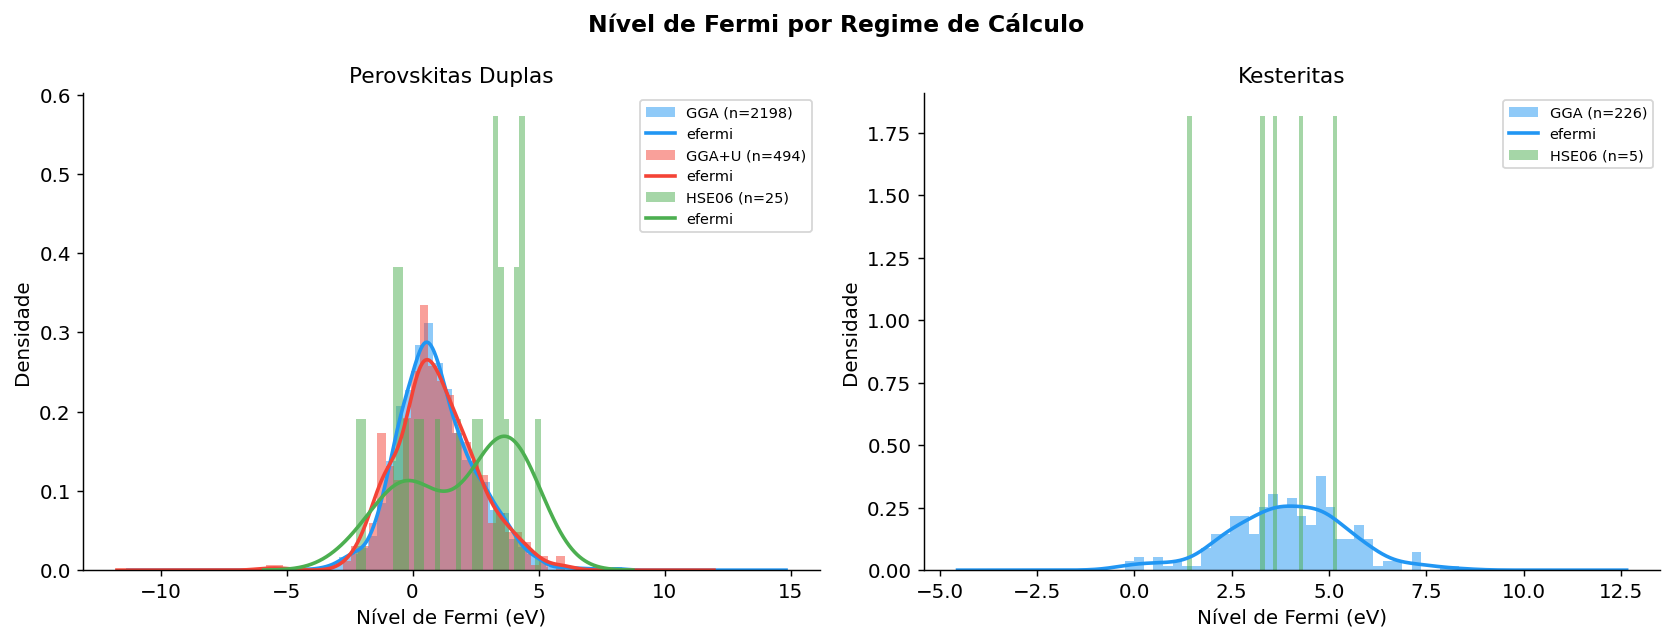

In [28]:
CORES_REGIME = {
    "GGA":          "#2196F3",
    "GGA+U":        "#F44336",
    "HSE06":        "#4CAF50",
    "r2SCAN":       "#FF9800",
    "desconhecido": "#AAAAAA",
}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Nível de Fermi por Regime de Cálculo",
             fontsize=13, fontweight="bold")

for ax, (chave, df) in zip(axes, [("perovskita", df_p), ("kesterita", df_k)]):
    cfg = FAMILIAS_PLOT[chave]
    sub = df[df["usar_em_analise"]]
    for regime in sub["regime_calc"].unique():
        if regime == "desconhecido":
            continue
        dados = sub[sub["regime_calc"] == regime]["efermi"].dropna()
        if len(dados) < 5:
            continue
        cor = CORES_REGIME.get(regime, "#999999")
        ax.hist(dados, bins=35, alpha=0.5, color=cor,
                density=True, label=f"{regime} (n={len(dados)})")
        if len(dados) > 20:
            dados.plot.kde(ax=ax, color=cor, linewidth=2)

    ax.set_xlabel("Nível de Fermi (eV)", fontsize=11)
    ax.set_ylabel("Densidade", fontsize=11)
    ax.set_title(cfg["label"], fontsize=12)
    ax.legend(fontsize=8)

plt.tight_layout()
caminho = os.path.join(PASTA_FIGURES, "fig5_efermi_por_regime.png")
plt.savefig(caminho, dpi=150, bbox_inches="tight")
print(f"Salvo: {caminho}")
plt.show()

### Fig. 6 — Mapa de Correlação entre Features

Salvo: /content/materials-solar-ml/figures/fig6_correlacoes.png


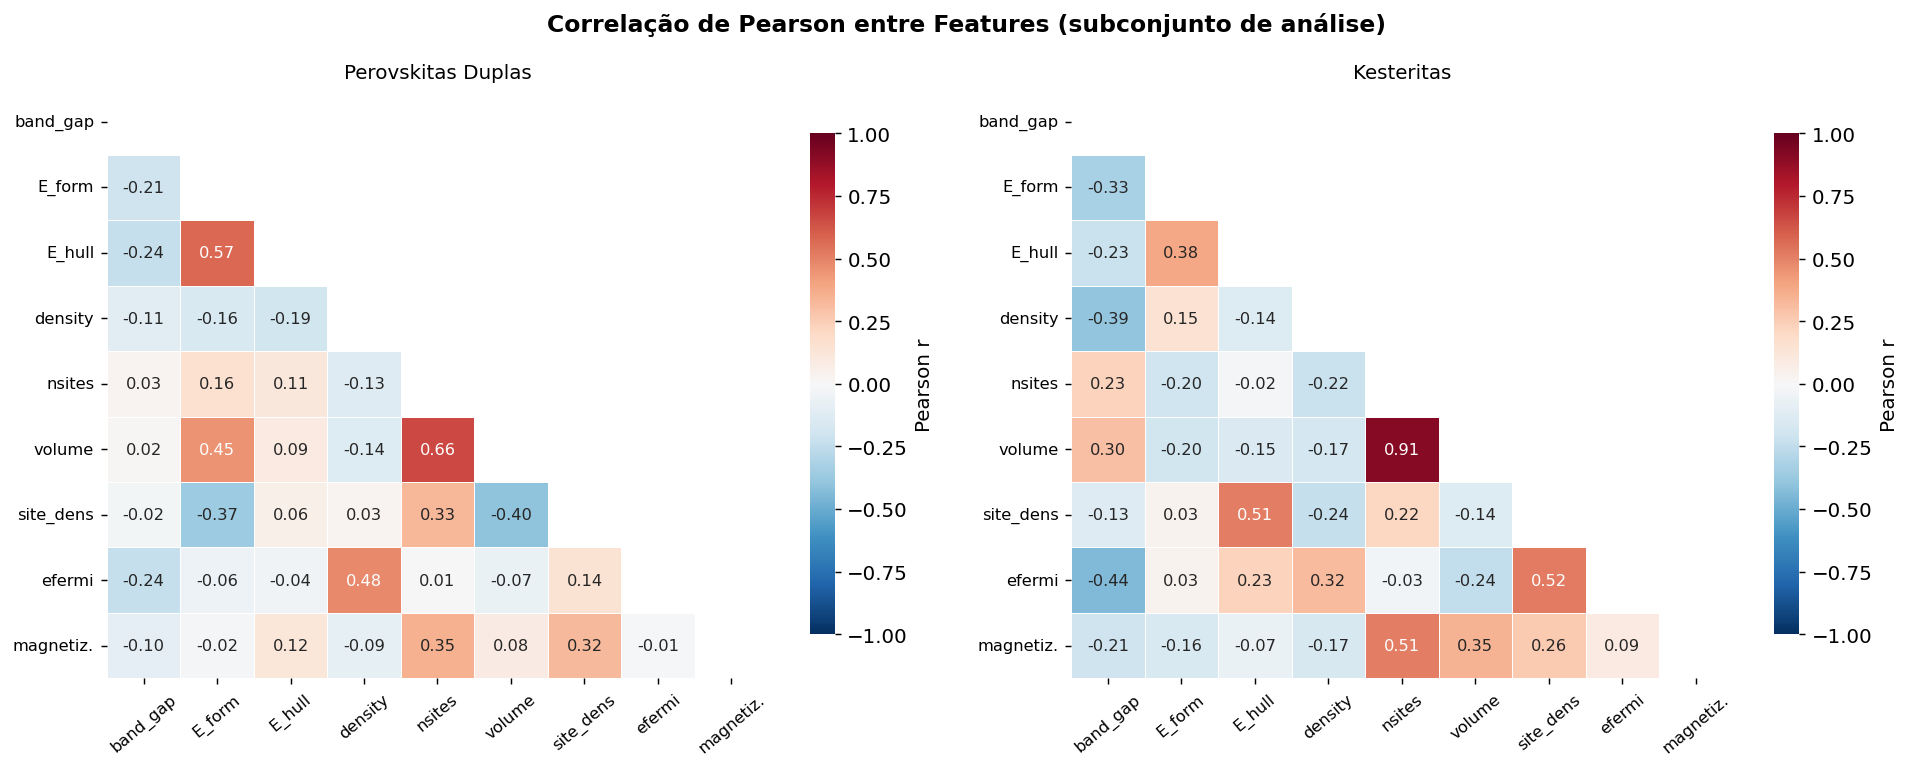

In [29]:
# Apenas features com cobertura suficiente (sem weighted_work_function, bulk_modulus)
FEAT_CORR = [
    "band_gap", "formation_energy_per_atom", "energy_above_hull",
    "density", "nsites", "volume", "site_density",
    "efermi", "total_magnetization",
]
NOMES_CURTOS = [
    "band_gap", "E_form", "E_hull",
    "density", "nsites", "volume", "site_dens",
    "efermi", "magnetiz.",
]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle("Correlação de Pearson entre Features (subconjunto de análise)",
             fontsize=13, fontweight="bold")

for ax, (chave, df) in zip(axes, [("perovskita", df_p), ("kesterita", df_k)]):
    cfg  = FAMILIAS_PLOT[chave]
    sub  = df[df["usar_em_analise"]]
    cols = [f for f in FEAT_CORR if f in sub.columns]
    nomes = [NOMES_CURTOS[FEAT_CORR.index(f)] for f in cols]
    corr  = sub[cols].dropna().corr()
    corr.columns = nomes
    corr.index   = nomes
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, mask=mask, ax=ax, annot=True, fmt=".2f",
                annot_kws={"size": 9}, cmap="RdBu_r",
                center=0, vmin=-1, vmax=1, linewidths=0.5,
                cbar_kws={"shrink": 0.85, "label": "Pearson r"})
    ax.set_title(cfg["label"], fontsize=11)
    ax.tick_params(axis="x", rotation=40, labelsize=9)
    ax.tick_params(axis="y", rotation=0,  labelsize=9)

plt.tight_layout()
caminho = os.path.join(PASTA_FIGURES, "fig6_correlacoes.png")
plt.savefig(caminho, dpi=150, bbox_inches="tight")
print(f"Salvo: {caminho}")
plt.show()

### Fig. 7 — Candidatos PV e IBSC

Salvo: /content/materials-solar-ml/figures/fig7_candidatos_scatter.png


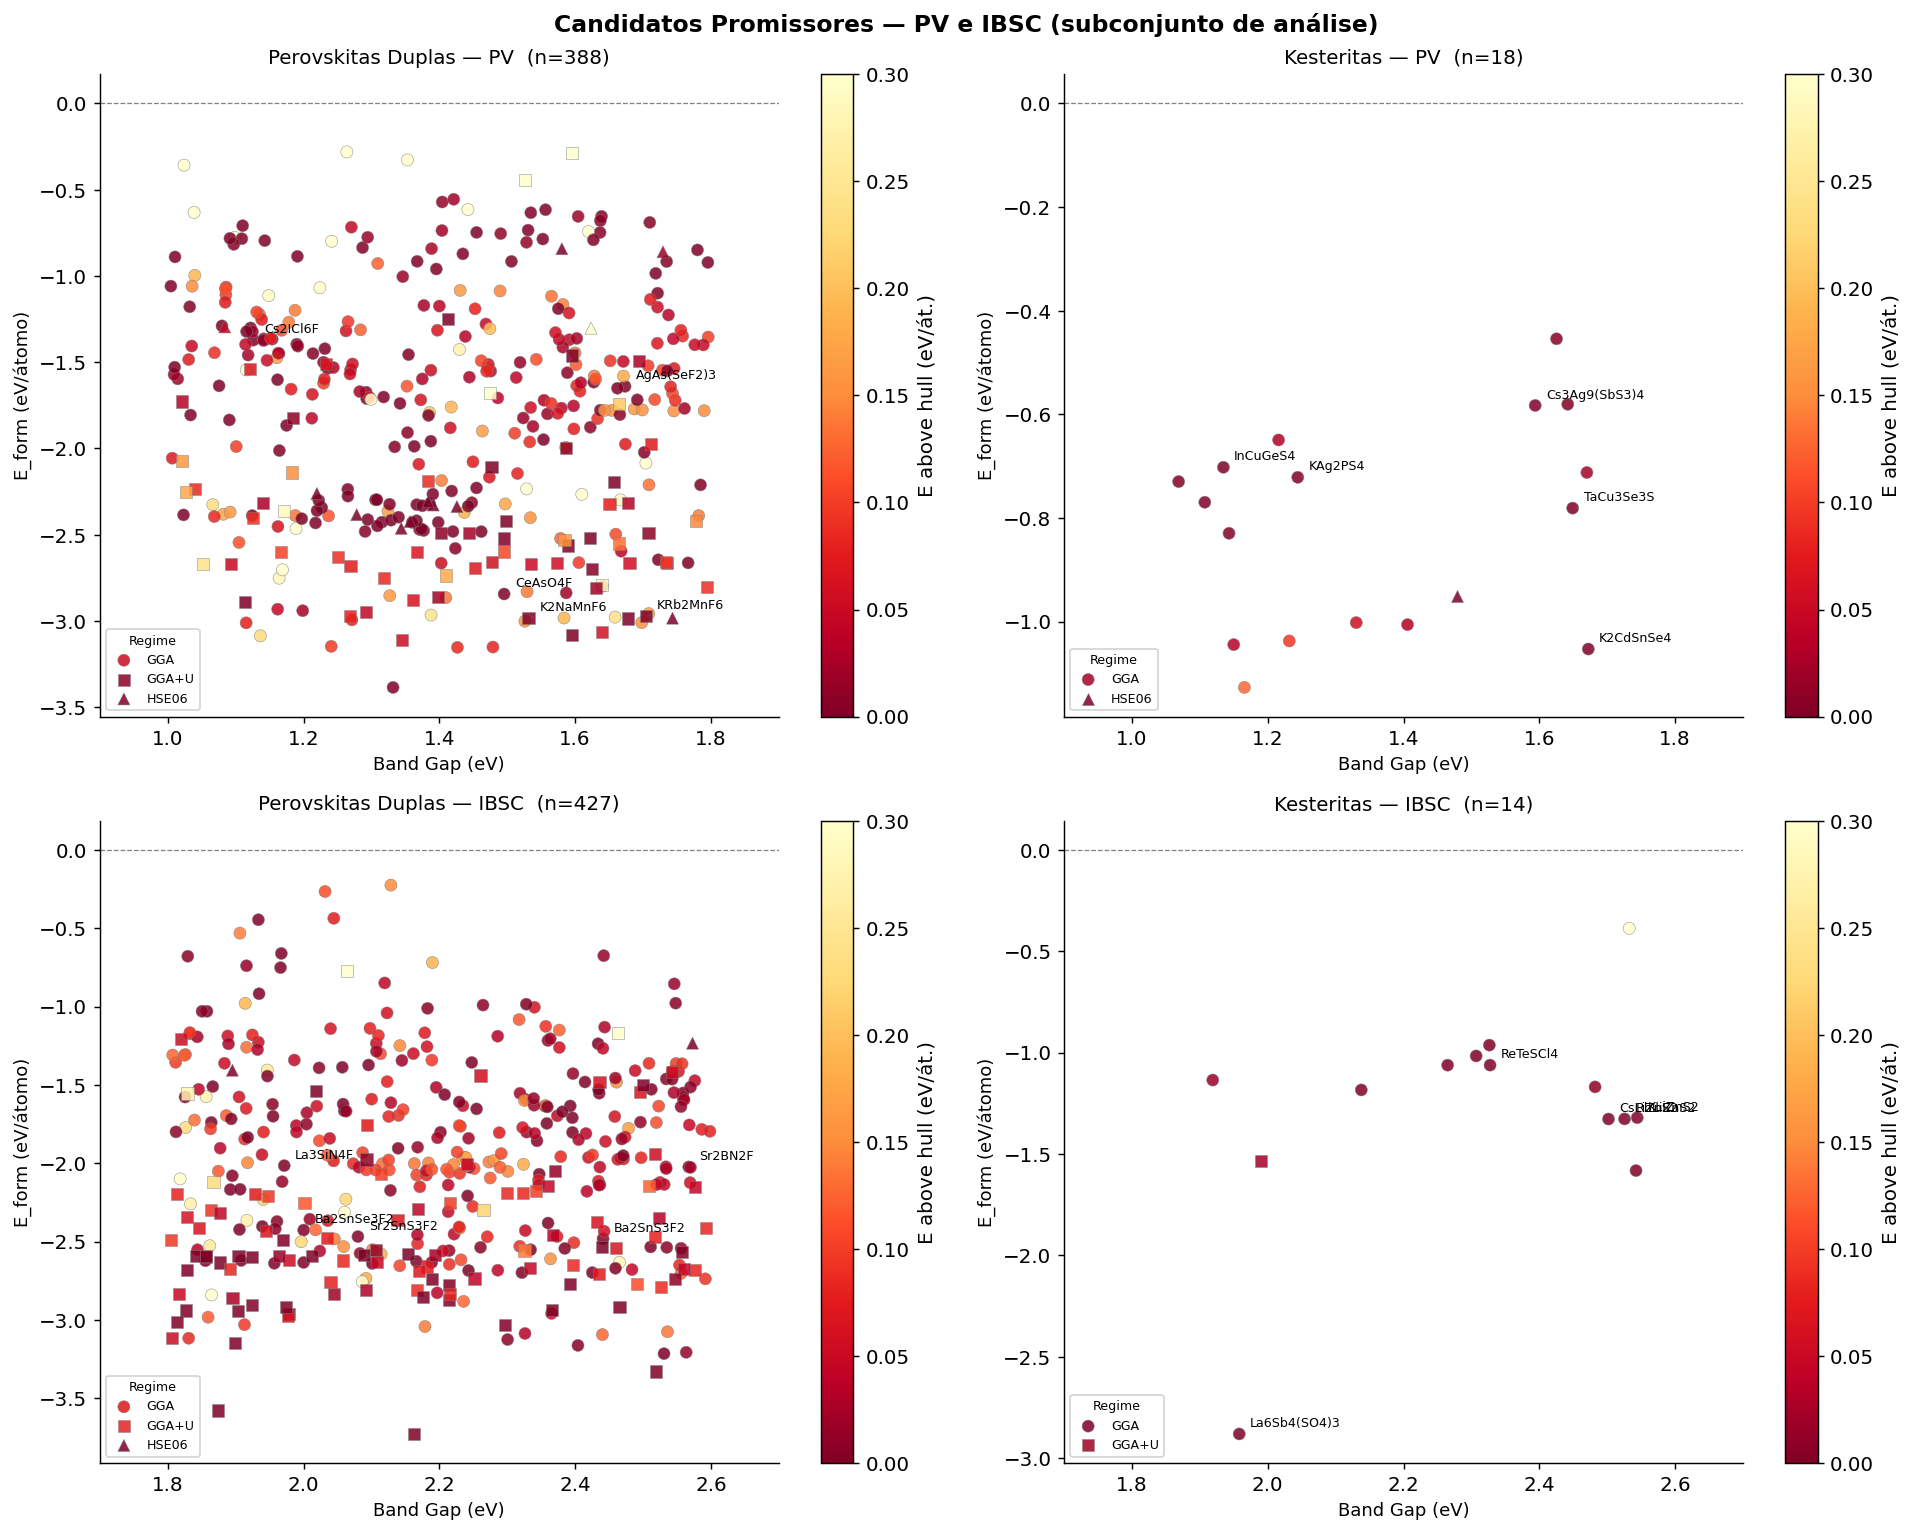

In [30]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle("Candidatos Promissores — PV e IBSC (subconjunto de análise)",
             fontsize=13, fontweight="bold")

pares = [
    (axes[0,0], "Perovskitas Duplas — PV",   df_p, "pv"),
    (axes[0,1], "Kesteritas — PV",           df_k, "pv"),
    (axes[1,0], "Perovskitas Duplas — IBSC", df_p, "ibsc"),
    (axes[1,1], "Kesteritas — IBSC",         df_k, "ibsc"),
]

for ax, titulo, df, tipo in pares:
    col_flag = "is_pv_candidate" if tipo == "pv" else "is_ibsc_candidate"
    xmin = PV_GAP_MIN - 0.1 if tipo == "pv" else PV_GAP_MAX - 0.1
    xmax = PV_GAP_MAX + 0.1 if tipo == "pv" else IBSC_GAP_MAX + 0.1

    sub = df[df["usar_em_analise"] & df[col_flag] &
             (df["formation_energy_per_atom"] < 0)].dropna(
        subset=["band_gap", "formation_energy_per_atom", "energy_above_hull"])

    if len(sub) == 0:
        ax.text(0.5, 0.5, "Sem candidatos", ha="center", va="center",
                transform=ax.transAxes, fontsize=12)
        ax.set_title(titulo, fontsize=11)
        continue

    # Marcador por regime de cálculo
    marcadores = {"GGA": "o", "GGA+U": "s", "HSE06": "^", "r2SCAN": "D"}
    for regime, marker in marcadores.items():
        s_reg = sub[sub["regime_calc"] == regime]
        if len(s_reg) == 0:
            continue
        sc = ax.scatter(s_reg["band_gap"], s_reg["formation_energy_per_atom"],
                        c=s_reg["energy_above_hull"], cmap="YlOrRd_r",
                        s=45, alpha=0.85, vmin=0, vmax=0.3,
                        marker=marker, edgecolors="gray", linewidths=0.3,
                        label=regime)

    plt.colorbar(
        plt.cm.ScalarMappable(cmap="YlOrRd_r",
                              norm=plt.Normalize(vmin=0, vmax=0.3)),
        ax=ax, label="E above hull (eV/át.)")

    for _, row in sub.nsmallest(5, "energy_above_hull").iterrows():
        ax.annotate(row["formula"],
                    (row["band_gap"], row["formation_energy_per_atom"]),
                    fontsize=7, xytext=(6, 4), textcoords="offset points",
                    arrowprops=dict(arrowstyle="-", color="gray", lw=0.5))

    ax.set_xlim(xmin, xmax)
    ax.axhline(0, color="gray", linewidth=0.7, linestyle="--")
    ax.set_xlabel("Band Gap (eV)", fontsize=10)
    ax.set_ylabel("E_form (eV/átomo)", fontsize=10)
    ax.set_title(f"{titulo}  (n={len(sub)})", fontsize=11)
    ax.legend(fontsize=7, title="Regime", title_fontsize=7)

plt.tight_layout()
caminho = os.path.join(PASTA_FIGURES, "fig7_candidatos_scatter.png")
plt.savefig(caminho, dpi=150, bbox_inches="tight")
print(f"Salvo: {caminho}")
plt.show()

## 11. Exportação dos Candidatos

Candidatos finais exportados com critérios explícitos:
- `usar_em_analise == True` (estrutura confirmada/relacionada + regime conhecido)
- `formation_energy_per_atom < 0` (termodinamicamente favorável)
- `energy_above_hull < HULL_THRESH` (quasi-estável)

In [31]:
COLS_CANDIDATOS = [
    "material_id", "formula", "band_gap", "is_gap_direct",
    "energy_above_hull", "formation_energy_per_atom",
    "crystal_system", "spacegroup_symbol", "spacegroup_number",
    "estrutura_esperada", "regime_calc", "density", "efermi",
    "theoretical", "has_experimental_ref", "possible_species",
]

def extrair_candidatos(df, tipo):
    col  = "is_pv_candidate" if tipo == "pv" else "is_ibsc_candidate"
    cols = [c for c in COLS_CANDIDATOS if c in df.columns]
    return (
        df[df["usar_em_analise"] & df[col] &
           (df["formation_energy_per_atom"] < 0) &
           (df["energy_above_hull"] < HULL_THRESH)]
        .sort_values(["estrutura_esperada", "energy_above_hull"])
        [cols]
        .reset_index(drop=True)
    )

cand_pv = pd.concat([
    extrair_candidatos(df_p, "pv").assign(familia="Perovskita Dupla"),
    extrair_candidatos(df_k, "pv").assign(familia="Kesterita"),
], ignore_index=True)

cand_ibsc = pd.concat([
    extrair_candidatos(df_p, "ibsc").assign(familia="Perovskita Dupla"),
    extrair_candidatos(df_k, "ibsc").assign(familia="Kesterita"),
], ignore_index=True)

exportar(cand_pv,   "candidatos_pv",   pasta=PASTA_PROCESSED)
exportar(cand_ibsc, "candidatos_ibsc", pasta=PASTA_PROCESSED)

print(f"\nCandidatos PV:   {len(cand_pv)}")
print(f"Candidatos IBSC: {len(cand_ibsc)}")

# Distribuição por regime nos candidatos
for nome, df_c in [("PV", cand_pv), ("IBSC", cand_ibsc)]:
    if "regime_calc" in df_c.columns:
        print(f"\nRegime nos candidatos {nome}:")
        print(df_c["regime_calc"].value_counts().to_string())

# Top 10 candidatos PV com estrutura confirmada
conf_pv = cand_pv[cand_pv["estrutura_esperada"].isin(["perovskita dupla","kesterita"])]
if len(conf_pv) > 0:
    print(f"\n── Top 10 candidatos PV com estrutura confirmada (n={len(conf_pv)}) ──")
    cols_p = ["formula","familia","band_gap","is_gap_direct",
              "energy_above_hull","estrutura_esperada","regime_calc"]
    cols_p = [c for c in cols_p if c in conf_pv.columns]
    print(conf_pv[cols_p].head(10).to_string(index=False))

  Exportado: /content/materials-solar-ml/data/processed/candidatos_pv.csv  (218 linhas, 17 colunas)
  Exportado: /content/materials-solar-ml/data/processed/candidatos_ibsc.csv  (228 linhas, 17 colunas)

Candidatos PV:   218
Candidatos IBSC: 228

Regime nos candidatos PV:
regime_calc
GGA      179
GGA+U     27
HSE06     12

Regime nos candidatos IBSC:
regime_calc
GGA      171
GGA+U     55
HSE06      2

── Top 10 candidatos PV com estrutura confirmada (n=152) ──
  formula          familia  band_gap  is_gap_direct  energy_above_hull estrutura_esperada regime_calc
 Cs2ICl6F Perovskita Dupla    1.1261           True                0.0   perovskita dupla         GGA
  CeAsO4F Perovskita Dupla    1.4955           True                0.0   perovskita dupla         GGA
 K2NaMnF6 Perovskita Dupla    1.5314           True                0.0   perovskita dupla       GGA+U
 KRb2MnF6 Perovskita Dupla    1.7047          False                0.0   perovskita dupla       GGA+U
Rb2NaMnF6 Perovskita Dupla

## 12. Resumo dos Arquivos Gerados

```
figures/
├── figA_gap_por_estrutura.png      ← gap por categoria estrutural
├── fig1_distribuicao_gap.png
├── fig2_estabilidade.png
├── fig3_formacao_vs_gap.png
├── fig4_sistemas_cristalinos.png
├── fig5_efermi_por_regime.png      ← efermi estratificado por regime
├── fig6_correlacoes.png
└── fig7_candidatos_scatter.png     ← marcadores por regime de cálculo

data/processed/
├── perovskita.csv                  ← colunas: estrutura_esperada, regime_calc,
├── kesterita.csv                       usar_em_analise, es_source_calc_id
├── candidatos_pv.csv
└── candidatos_ibsc.csv
```

## 13. Próximos Passos — Fase 2

**Decisão imediata:** com base na Seção 9, confirmar se análises seguintes
usam `usar_em_analise == True` como filtro padrão ou se análises específicas
justificam incluir "relacionada".

**Fase 2 — Descritores composicionais:**
```python
from matminer.featurizers.composition import ElementProperty
from pymatgen.core import Composition

df = carregar("perovskita")
df = df[df["usar_em_analise"]]   # filtro padrão
df["composition"] = df["formula"].apply(Composition)

ep = ElementProperty.from_preset("magpie")  # 114 features
df = ep.featurize_dataframe(df, "composition", ignore_errors=True)
```

**`possible_species` — Fase 2/3:**
Após restringir ao subconjunto confirmado, usar para verificar balanço de
cargas e como feature adicional. Descritores de eletronegatividade e raio
atômico dos elementos componentes (motivados pelo doutorado em IBSC)
serão adicionados manualmente como features de alto valor interpretativo.